# Figure6_4

In [1]:
# Figure 6_4 setup: shared config, theme, and imports
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
from matplotlib.ticker import MaxNLocator
from PIL import Image

from functions.load_data import loadTrialsM
from functions.utils import split_with_image
from functions.decoding import load_feature_mat
from functions.sensitivity import TRAIN_TASK_MAP, mean_sensitivity, extract_image_basename
from functions.plotting import set_paper_theme, plot_linear_fit_ci

set_paper_theme(unicode_minus=False)

RESULTS_DIR = "results/Figure6"
OUT_DIR = "results/Figure6"
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

MONKEYS = ["Elsa", "Judy", "Olaf"]

# 6 small tasks -> monkey training task / model feature file names.
ANALYSIS1_TASKS = [
    "Animate vs. Inanimate",
    "Natural vs. Artificial",
    "Mammal vs. Non-mammal",
    "Tools vs. Electronics",
    "Human vs. Monkey",
    "Monkey vs. Mammal",
]

FEATURE_TASK_MAP = {
    "Animate vs. Inanimate": "animate_vs_inanimate",
    "Natural vs. Artificial": "natural_vs_artificial",
    "Mammal vs. Non-mammal": "mammal_vs_reptile",
    "Tools vs. Electronics": "electronics_vs_tools",
    "Human vs. Monkey": "human_vs_monkey",
    "Monkey vs. Mammal": "monkey_vs_mammal",
}

ANALYSIS1_MODELS = ["alexnet", "vgg16", "resnet50", "vit_b_32"]
TYPICALITY_MODES = ("relative-rule", "within-basicCategory")

# Task display names (short) for the panel
A1_TASKS_SHORT = [
    "Animate vs. Inanimate",
    "Natural vs. Artificial",
    "Mammal vs. Non-mammal",
    "Tools vs. Electronics",
    "Human vs. Monkey",
    "Monkey vs. Mammal",
]

print("Setup complete.")


Setup complete.


## Analysis 1 — image-level model-feature typicality vs training behavior

In [2]:
_BASIC_CATEGORY_MAP = None


def get_basic_category_map():
    """Lazy {image filename -> basic category} map from Image_Info.csv
    (Path column: .../basic_category/file)."""
    global _BASIC_CATEGORY_MAP
    if _BASIC_CATEGORY_MAP is None:
        img = pd.read_csv("data_behavior/Image_Info.csv")
        img["basic_category"] = img["Path"].apply(lambda x: x.split("/")[-2])
        img["filename"] = img["Path"].apply(lambda x: x.split("/")[-1])
        _BASIC_CATEGORY_MAP = dict(zip(img["filename"], img["basic_category"]))
    return _BASIC_CATEGORY_MAP


def _safe_corr(x, y, func):
    """(r, p), with (nan, nan) for degenerate input."""
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=RuntimeWarning)
            r, p = func(x, y)
    except Exception:
        r, p = np.nan, np.nan
    if not (np.isfinite(r) and np.isfinite(p)):
        r, p = np.nan, np.nan
    return r, p


def correlation(method, x, y):
    """Pearson or Spearman correlation, returning (r, p) with NaN on failure."""
    func = pearsonr if method == "pearson" else spearmanr
    return _safe_corr(x, y, func)


def compute_image_typicality(feature_path, mode="relative-rule", basic_cat_map=None):
    """Return per-image typicality with an explicit reference definition.

    relative-rule: C-E, using all task images; C excludes the image itself.
    within-rule: C alone, retained as an optional baseline.
    within-basicCategory: original same-basic-category mean correlation.
    """
    X, category, fnames_raw = load_feature_mat(feature_path)
    fnames = np.array([extract_image_basename(s) for s in fnames_raw])
    cats = np.array([c.strip().lower() for c in category])
    corr = np.corrcoef(X)
    indices = np.arange(len(fnames))
    correct = np.full(len(fnames), np.nan)
    error = np.full(len(fnames), np.nan)
    for i in indices:
        same = (cats == cats[i]) & (indices != i)
        opposite = cats != cats[i]
        if same.any():
            correct[i] = corr[i, same].mean()
        if opposite.any():
            error[i] = corr[i, opposite].mean()
    result = pd.DataFrame({"image": fnames, "category": cats,
                           "C": correct, "E": error})
    if mode == "relative-rule":
        result["typicality"] = correct - error
    elif mode == "within-rule":
        result["typicality"] = correct
    elif mode == "within-basicCategory":
        if basic_cat_map is None:
            basic_cat_map = get_basic_category_map()
        basic = np.array([basic_cat_map.get(fn, None) for fn in fnames])
        typicality = np.full(len(fnames), np.nan)
        for i in indices:
            same = (basic == basic[i]) & (indices != i)
            if basic[i] is not None and same.any():
                typicality[i] = corr[i, same].mean()
        result["basic_category"] = basic
        result["typicality"] = typicality
    else:
        raise ValueError(f"Unknown typicality mode: {mode}")
    return result


def load_monkey_learned_trials(task_name, monkeys=MONKEYS, verbose=False):
    """ALL monkey TRAINING trials for a small task, restricted to
    islearn == True (sessions marked `learned == True` in the per-monkey Excel
    index), as a flat list across all learned sessions of all monkeys."""
    train_task = TRAIN_TASK_MAP.get(task_name)
    if not train_task:
        return None
    all_trials = []
    for monkey in monkeys:
        try:
            trials, _ = loadTrialsM(train_task, monkey, verbose=verbose,
                                    islearn=True, extend=True,
                                    root="data_behavior/Monkey")
        except Exception as e:
            if verbose:
                print(f"  warn: could not load {train_task} for {monkey}: {e}")
            continue
        if not trials:
            continue
        if verbose:
            print(f"  {monkey}/{train_task}: {len(trials)} trials (islearn=True)")
        all_trials.extend(trials)
    return all_trials


def per_image_correct_rate(trials):
    """Per-image correct rate from a flat list of trials."""
    if len(trials) == 0:
        return pd.DataFrame(columns=["image", "correct_rate", "n"])
    trials_image, uimages = split_with_image(trials)
    rows = []
    for i, im in enumerate(uimages):
        tlist = trials_image[i]
        if len(tlist) == 0:
            continue
        results = [tr.get("result") for tr in tlist]
        corr = sum(1 for r in results if r == "CORRECT") / len(results)
        rows.append({"image": im, "correct_rate": corr, "n": len(results)})
    return pd.DataFrame(rows)


def per_image_rt(trials, correct_only=False):
    """Per-image mean RT from a flat list of trials."""
    if len(trials) == 0:
        return pd.DataFrame(columns=["image", "mean_rt", "n"])
    trials_image, uimages = split_with_image(trials)
    rows = []
    for i, im in enumerate(uimages):
        tlist = trials_image[i]
        if correct_only:
            tlist = [tr for tr in tlist if tr.get("result") == "CORRECT"]
        if len(tlist) == 0:
            continue
        rts = [tr.get("rt") for tr in tlist
               if tr.get("rt") is not None and np.isfinite(tr.get("rt"))]
        if len(rts) == 0:
            continue
        rows.append({"image": im, "mean_rt": np.mean(rts), "n": len(rts)})
    return pd.DataFrame(rows)


In [3]:
# Analysis 1 skeleton: per-task loop over the 6 small tasks tying the
# generic helpers together.
def run_analysis1(model, modes=TYPICALITY_MODES, verbose=True):
    """Run Analysis 1 for one model feature set.

    For each small task: compute image-level typicality (relative-rule C-E /
    within-basicCategory) from the model feature file, load monkey TRAINING
    behavior (per-image correct rate, mean RT) and per-image signed DDM
    sensitivity (monkey and human), then correlate typicality with each
    metric (Pearson and Spearman).

    Returns a DataFrame with columns task, typicality_mode, metric, method,
    r, p, n. metric is one of correct_rate, mean_rt, sensitivity (monkey),
    sensitivity_human.
    """
    rows = []
    for task in ANALYSIS1_TASKS:
        feat_name = FEATURE_TASK_MAP[task]
        path = f"data_model/smalltask_features/{feat_name}_{model}.mat"
        if not os.path.exists(path):
            if verbose:
                print(f"  skip {task}: feature file not found: {path}")
            continue

        # Evaluate the requested definitions with the same reference images.
        typ_by_mode = {mode: compute_image_typicality(path, mode=mode)
                       for mode in modes}

        if "relative-rule" in typ_by_mode:
            typ_by_mode["relative-rule"].to_csv(
                f"{RESULTS_DIR}/Figure6_4_relative_typicality_{model}_{feat_name}.csv", index=False)

        trials = load_monkey_learned_trials(task, verbose=verbose)
        if not trials:
            if verbose:
                print(f"  skip {task}: no trials")
            continue
        corr_df = per_image_correct_rate(trials)
        rt_df = per_image_rt(trials, correct_only=False)
        # Signed DDM sensitivity (positive = drift toward the correct
        # category), aligned by image name only, independently of the
        # behavioral trial frames above.
        sens_df = mean_sensitivity(task, species="monkey")
        sens_h_df = mean_sensitivity(task, species="human")

        for mode, typ_df in typ_by_mode.items():
            ref_imgs = set(typ_df["image"])
            c = corr_df[corr_df["image"].isin(ref_imgs)]
            r = rt_df[rt_df["image"].isin(ref_imgs)]
            m = c.merge(typ_df[["image", "typicality"]], on="image",
                        how="inner").dropna(subset=["typicality"])
            mr = r.merge(typ_df[["image", "typicality"]], on="image",
                         how="inner").dropna(subset=["typicality"])
            ms = None
            if sens_df is not None:
                ms = sens_df.merge(typ_df[["image", "typicality"]], on="image",
                                   how="inner").dropna(subset=["typicality", "sensitivity"])
            mh = None
            if sens_h_df is not None:
                mh = sens_h_df.merge(typ_df[["image", "typicality"]], on="image",
                                     how="inner").dropna(subset=["typicality", "sensitivity"])
            if verbose:
                print(f"  {task} [{mode}]: n_corr={len(m)} n_rt={len(mr)} "
                      f"n_sens={0 if ms is None else len(ms)} "
                      f"n_sens_h={0 if mh is None else len(mh)}")
            if len(m) > 2:
                for method in ("pearson", "spearman"):
                    rr, pp = correlation(method, m["typicality"], m["correct_rate"])
                    rows.append(dict(task=task, typicality_mode=mode,
                                     metric="correct_rate", method=method,
                                     r=rr, p=pp, n=len(m)))
            if len(mr) > 2:
                for method in ("pearson", "spearman"):
                    rr, pp = correlation(method, mr["typicality"], mr["mean_rt"])
                    rows.append(dict(task=task, typicality_mode=mode,
                                     metric="mean_rt", method=method,
                                     r=rr, p=pp, n=len(mr)))
            if ms is not None and len(ms) > 2:
                for method in ("pearson", "spearman"):
                    rr, pp = correlation(method, ms["typicality"], ms["sensitivity"])
                    rows.append(dict(task=task, typicality_mode=mode,
                                     metric="sensitivity", method=method,
                                     r=rr, p=pp, n=len(ms)))
            if mh is not None and len(mh) > 2:
                for method in ("pearson", "spearman"):
                    rr, pp = correlation(method, mh["typicality"], mh["sensitivity"])
                    rows.append(dict(task=task, typicality_mode=mode,
                                     metric="sensitivity_human", method=method,
                                     r=rr, p=pp, n=len(mh)))
    return pd.DataFrame(rows)

In [4]:
# Analysis 1 execution.
# Figure6_4 needs alexnet only (fastest); set MODELS1 = ANALYSIS1_MODELS to
# run all four models (each model takes ~1-2 min).
MODELS1 = ["alexnet"]

df1 = {}
for m in MODELS1:
    print(f"\n=== Analysis 1: model={m} ===")
    df1[m] = run_analysis1(m, verbose=True)
    csv_path = f"{RESULTS_DIR}/analysis1_train_correct_rate_{m}_correlations_pearson_spearman.csv"
    df1[m].to_csv(csv_path, index=False)
    print(f"Saved -> {csv_path} ({len(df1[m])} rows)")

print("\nAnalysis 1 done.")


=== Analysis 1: model=alexnet ===
data_behavior/Monkey/animate_vs_inanimate/Elsa20230722_01_fmt.mat Trials Num:765
data_behavior/Monkey/animate_vs_inanimate/Elsa20230724_01_fmt.mat Trials Num:863
data_behavior/Monkey/animate_vs_inanimate/Elsa20230725_01_fmt.mat Trials Num:758
data_behavior/Monkey/animate_vs_inanimate/Elsa20230726_01_fmt.mat Trials Num:548
data_behavior/Monkey/animate_vs_inanimate/Elsa20230731_01_fmt.mat Trials Num:796
  Elsa/animate_vs_inanimate: 3730 trials (islearn=True)
data_behavior/Monkey/animate_vs_inanimate/Judy20230515_01_fmt.mat Trials Num:772
data_behavior/Monkey/animate_vs_inanimate/Judy20230516_01_fmt.mat Trials Num:647
data_behavior/Monkey/animate_vs_inanimate/Judy20230517_01_fmt.mat Trials Num:693
data_behavior/Monkey/animate_vs_inanimate/Judy20230518_01_fmt.mat Trials Num:755
  Judy/animate_vs_inanimate: 2867 trials (islearn=True)
data_behavior/Monkey/animate_vs_inanimate/Olaf20230811_01_fmt.mat Trials Num:986
data_behavior/Monkey/animate_vs_inanimate/O

## Panel J - Natural vs. Artificial example scatter plot

n = 80
spearman = 0.485 (p = 5.209e-06), pearson = 0.570 (p = 3.487e-08)


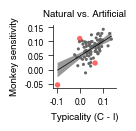

Saved -> results/Figure6/typicality_sensitivity_example_natural_vs_artificial.pdf


In [5]:
# Example scatter: per-image typicality vs signed DDM sensitivity (monkey),
# Natural vs. Artificial (the task selected as the manuscript example).
# Style follows the Figure6_2 example panels (gray dots + linear fit + 95% CI
# band), plus panel-E-style example points marked in red; gray stimulus
# thumbnails (results/Thumbnail/GenerateThumbnail.m) are drawn near the panel
# corners. layout='none' + bbox_inches='tight': constrained_layout +
# box_aspect(1) pushes the axis labels outside the canvas.
task = "Natural vs. Artificial"
feat_name = FEATURE_TASK_MAP[task]
typ_df = compute_image_typicality(
    f"data_model/smalltask_features/{feat_name}_alexnet.mat", mode="relative-rule")
sens_df = mean_sensitivity(task, species="monkey")
sc = sens_df.merge(typ_df[["image", "typicality"]], on="image", how="inner")
sc = sc.dropna(subset=["typicality", "sensitivity"])

x = sc["typicality"].to_numpy()
y = sc["sensitivity"].to_numpy()
print(f"n = {len(sc)}")
sr, sp = spearmanr(x, y)
pr, pp = pearsonr(x, y)
print(f"spearman = {sr:.3f} (p = {sp:.4g}), pearson = {pr:.3f} (p = {pp:.4g})")

fig, ax = plt.subplots(layout="none")
fig.set(figwidth=90 / 75, figheight=90 / 75)
ax.set_box_aspect(1)

plot_linear_fit_ci(ax, x, y)

ax.set_title(task)
ax.set_xlabel("Typicality (C - I)")
ax.set_ylabel("Monkey sensitivity")
ax.xaxis.set_major_locator(MaxNLocator(nbins=3))
ax.margins(x=0.08)
ax.set_yticks([-0.05, 0.00, 0.05, 0.10, 0.15])

# --- Panel-E-style example thumbnails (Figure6_2 convention) --------------
# Fixed example points: the left-bottom corner point (atypical artificial
# image with negative sensitivity), a right-bottom point (below the fit) and
# a left-top point (above the fit).
THUMB_DIR = "results/Thumbnail/natural_vs_artificial_thumbnail"
EXP_IMG = ["010806201732.png",  # left-bottom: atypical, negative sensitivity
           "010800601574.png",  # right-bottom: below the fit
           "010605101293.png"]  # left-top: above the fit
EXP_POS = [(-0.055, -0.030),    # thumbnail centers in data coords
           (0.108, 0.008),
           (-0.070, 0.122)]
THUMB_SIZE_PT = 15  # Physical width and height in PDF points.

thumb_mask = sc["image"].isin(EXP_IMG).to_numpy()
ax.scatter(x[~thumb_mask], y[~thumb_mask], s=5, color="#666666",
           edgecolors="None")
ax.scatter(x[thumb_mask], y[thumb_mask], s=15, color=("red", 0.6),
           edgecolors="None", zorder=5)

# Freeze the autoscale limits BEFORE adding thumbnails: imshow otherwise
# resets the data limits to the image extents and the scatter disappears.
# Explicit limits include every point and prevent image-induced clipping.
ax.set_xlim(-0.115, 0.155)
ax.set_ylim(-0.065, 0.160)
xlim, ylim = ax.get_xlim(), ax.get_ylim()

fig.canvas.draw()
axes_size = ax.get_window_extent().transformed(fig.dpi_scale_trans.inverted())
thumb_w = THUMB_SIZE_PT / 72 / axes_size.width * (xlim[1] - xlim[0])
thumb_h = THUMB_SIZE_PT / 72 / axes_size.height * (ylim[1] - ylim[0])
assert sc["image"].isin(EXP_IMG).sum() == 3
for fname, (cx, cy) in zip(EXP_IMG, EXP_POS):
    if not os.path.isfile(os.path.join(THUMB_DIR, fname)):
        continue  # Optional licensed stimulus thumbnail.
    point = sc.loc[sc["image"].eq(fname)].iloc[0]
    # The thumbnail covers the inner part of the connector.
    ax.plot([point["typicality"], cx], [point["sensitivity"], cy],
            color="black", linewidth=0.5, zorder=3)
    img = Image.open(os.path.join(THUMB_DIR, fname)).convert("L")
    # Preserve the original image pixels and exact physical PDF dimensions.
    ax.imshow(img, cmap="gray", vmin=0, vmax=255, interpolation="none",
              extent=[cx - thumb_w / 2, cx + thumb_w / 2,
                      cy - thumb_h / 2, cy + thumb_h / 2],
              aspect="auto", zorder=4)
ax.set_xlim(xlim)
ax.set_ylim(ylim)

plt.savefig(f"{OUT_DIR}/typicality_sensitivity_example_{feat_name}.pdf",
            transparent=True, bbox_inches="tight", dpi=600)
plt.show()
print(f"Saved -> {OUT_DIR}/typicality_sensitivity_example_{feat_name}.pdf")


## Panel K - Typicality-sensitivity correlations across six tasks

Figure6_4 data (Spearman r, C-E vs signed sensitivity):
                  task        r        p  n
 Animate vs. Inanimate 0.394059 0.000071 96
Natural vs. Artificial 0.484716 0.000005 80
 Mammal vs. Non-mammal 0.425645 0.000083 80
 Tools vs. Electronics 0.163291 0.147822 80
      Human vs. Monkey 0.544540 0.000007 60
     Monkey vs. Mammal 0.392942 0.001899 60


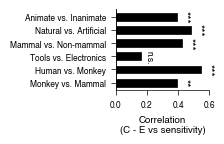

Saved -> results/Figure6/typicality_sensitivity_correlation_by_task.pdf


In [6]:
sel = df1["alexnet"][
    (df1["alexnet"]["typicality_mode"] == "relative-rule")
    & (df1["alexnet"]["metric"] == "sensitivity")
    & (df1["alexnet"]["method"] == "spearman")
].copy()
sel["__ord__"] = sel["task"].map({t: i for i, t in enumerate(A1_TASKS_SHORT)})
sel = sel.sort_values("__ord__").reset_index(drop=True)

print("Figure6_4 data (Spearman r, C-E vs signed sensitivity):")
print(sel[["task", "r", "p", "n"]].to_string(index=False))

# Horizontal bar chart: task labels on the y-axis (left), bars extend right.
# Labels no longer depend on bar length, so short / negative bars stay readable.
fig, ax = plt.subplots()
fig.set(figwidth=160 / 75, figheight=100 / 75)

ys = np.arange(len(sel))[::-1]   # top-down order matches A1_TASKS_SHORT
rs = sel["r"].values
ax.barh(ys, rs, height=0.6, color="black", edgecolor="black", linewidth=0.5)
ax.axvline(0, color="black", linewidth=0.5)

# Two-sided, uncorrected Spearman p values; rotate labels as in the reference.
def significance_label(p):
    if not np.isfinite(p):
        raise ValueError("Cannot annotate a non-finite p value")
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "n.s."

sel["significance"] = sel["p"].map(significance_label)
for y, r, label in zip(ys, rs, sel["significance"]):
    ax.annotate(label, xy=(r, y), xytext=(2, 0),
                textcoords="offset points", ha="left", va="center",
                rotation=-90, fontfamily="Helvetica",
                fontsize=8 if label != "n.s." else 6)


ax.set_yticks(ys)
ax.set_yticklabels(sel["task"], fontsize=6)
ax.set_xlabel("Correlation\n(C - E vs sensitivity)")
ax.set_xlim(0.0, max(0.4, np.ceil(rs.max() * 10) / 10))
ax.set_xticks([0.0, 0.2, 0.4, 0.6])
ax.set_xticklabels(["0.0", "0.2", "0.4", "0.6"])
ax.tick_params(axis="x", labelsize=6)

plt.savefig(f"{OUT_DIR}/typicality_sensitivity_correlation_by_task.pdf")
plt.show()
print(f"Saved -> {OUT_DIR}/typicality_sensitivity_correlation_by_task.pdf")